**Publication execution note:** Existing outputs are historical and were preserved, not regenerated. Inputs resolve relative to the publication layout. New runs write to unique `runs/` directories, never to published models or results.

The 900 balanced cross-cell curves come from a second Candida albicans cell. AtomicJ ROI selection experimentally defined Nanodomain, Intermediate and Outside, with 300 curves per class. Later computational processing restored filename/class organization after anonymization/random renaming; restoration metadata did not define biological labels. Both balanced test archives represent the same cohort.

# CNN for *Candida albicans* AFM Force-Distance Curve Classification
## Binary classification — Nanodomain vs Outside with L2 regularisation

This notebook implements the final controlled **binary classification experiment** using the
same selected CNN architecture and training protocol as the multiclass L2 model.

The purpose is to evaluate the simplified discrimination problem involving the two most
distinct nanoadhesive regimes:

- **Nanodomain**
- **Outside**

The Intermediate class is deliberately excluded.

### Controlled protocol
- source dataset: the same balanced 3-class dataset used in the main experiments;
- binary subset: 1,000 Nanodomain + 1,000 Outside images;
- total: 2,000 images;
- 80:20 hold-out split: 1,600 training / 400 validation images;
- input: 224 × 224 × 3;
- architecture: Conv32 → Conv64 → Conv128 → Conv256 → Conv256 → Dense512 → Dense128 → Softmax2;
- L2 = 0.001 on the five convolutional and two hidden dense layers;
- Adam learning rate = 1 × 10⁻⁴;
- batch size = 32;
- maximum 50 epochs;
- `SEED = 42`;
- no data augmentation;
- no Dropout;
- no class weighting or resampling;
- best checkpoint selected by minimum validation loss.

The model is saved as:

`Models/CNN_CAlbicans_Binary_L2.h5`

An optional independent cross-cell binary evaluation is included. It runs only if a
`cross_cell_label_mapping.csv` file containing the exact `filename,true_label` correspondence is
available; otherwise the notebook completes normally without reporting sample-level
independent-test metrics.

In [1]:
# Portable publication layout; no machine-specific paths.
from pathlib import Path
import tempfile
_start = Path.cwd().resolve()
_roots = [p for p in (_start, *_start.parents)
          if (p / "notebooks").is_dir() and (p / "data/manifest.csv").is_file()]
if not _roots:
    raise FileNotFoundError("Start the kernel in the publication root or a notebook subdirectory.")
PROJECT_ROOT = _roots[0]
_candidates = [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent / "zenodo"]
ASSET_ROOT = next((p for p in _candidates
                   if (p / "data/candida_balanced_dataset.zip").is_file()), None)
if ASSET_ROOT is None:
    raise FileNotFoundError("Place Zenodo data/ and models/ in the publication root, or use the Zenodo github_snapshot layout.")
DATA_DIR = ASSET_ROOT / "data"
LABEL_MAPPING = PROJECT_ROOT / "data/labels/cross_cell_label_mapping.csv"
PUBLISHED_MODEL = ASSET_ROOT / "models/binary/l2.h5"
_run_parent = PROJECT_ROOT / "runs/binary/l2"
_run_parent.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix="run-", dir=_run_parent))


from pathlib import Path
import os
import shutil
import zipfile
import time
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations: enabled")
except Exception as exc:
    print(f"TensorFlow deterministic operations could not be enabled: {exc}")

# -------------------------------------------------------------------------
# Experiment configuration
# -------------------------------------------------------------------------
EXPERIMENT_NAME = "CNN_CAlbicans_Binary_L2"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
L2_FACTOR = 1e-3

DATA_ZIP = (DATA_DIR / "candida_balanced_dataset.zip")

# Optional independent cross-cell test.
TEST_ZIP = (DATA_DIR / "candida_cross_cell_test_balanced_original.zip")
GROUND_TRUTH_CSV = LABEL_MAPPING

WORK_DIR = (RUN_DIR / "work")
TRAIN_EXTRACT_DIR = WORK_DIR / "training"
TEST_EXTRACT_DIR = WORK_DIR / "testing"

MODEL_DIR = (RUN_DIR / "models")
RESULTS_DIR = (RUN_DIR / "results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "l2.h5"

print("TensorFlow version:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Model output path:", MODEL_PATH)
print("L2 factor:", L2_FACTOR)


2026-08-27 22:25:36.211677: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-27 22:25:36.444017: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-27 22:25:36.444063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-27 22:25:36.453737: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-27 22:25:36.484821: I tensorflow/core/platform/cpu_feature_guar

TensorFlow deterministic operations: enabled
TensorFlow version: 2.15.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: CNN_CAlbicans_Binary_L2
Model output path: Models/CNN_CAlbicans_Binary_L2.h5
L2 factor: 0.001


2026-08-27 22:25:40.194212: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 22:25:40.450465: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 22:25:40.450567: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:

def extract_zip_clean(zip_path, destination):
    destination = Path(destination)
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(destination)

    return destination


def locate_class_root(root, expected_classes):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]

    for candidate in candidates:
        children = {p.name for p in candidate.iterdir() if p.is_dir()}
        if set(expected_classes).issubset(children):
            return candidate

    raise RuntimeError(
        f"Could not find a directory containing all classes: {expected_classes}"
    )


def class_names_from_iterator(iterator):
    ordered = sorted(
        iterator.class_indices.items(),
        key=lambda item: item[1],
    )
    return [name for name, _ in ordered]


def natural_number_key(path):
    match = re.search(r"(\d+)(?=\.[^.]+$)", Path(path).name)
    return int(match.group(1)) if match else Path(path).name


## 1. Binary dataset construction

The binary experiment uses only **Nanodomain** and **Outside** images from the same balanced
dataset used for the multiclass analysis. No new images are selected and the Intermediate
class is excluded.

The original dataset contains 1,000 images for each of the two retained classes. The same
80:20 hold-out procedure therefore produces:

- training: 800 Nanodomain + 800 Outside = **1,600 images**;
- validation: 200 Nanodomain + 200 Outside = **400 images**.

In [3]:

BINARY_CLASSES = ["Nanodomain", "Outside"]
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

extract_zip_clean(DATA_ZIP, TRAIN_EXTRACT_DIR)
base_dir = locate_class_root(TRAIN_EXTRACT_DIR, BINARY_CLASSES)

print("Dataset root:", base_dir)

original_counts = {
    class_name: sum(
        1
        for p in (base_dir / class_name).rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    )
    for class_name in BINARY_CLASSES
}

print("Original binary class counts:", original_counts)

assert original_counts == {
    "Nanodomain": 1000,
    "Outside": 1000,
}, f"Unexpected binary dataset composition: {original_counts}"

data_generator = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.20,
)

train_iterator = data_generator.flow_from_directory(
    base_dir,
    classes=BINARY_CLASSES,
    subset="training",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
)

validation_iterator = data_generator.flow_from_directory(
    base_dir,
    classes=BINARY_CLASSES,
    subset="validation",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
)

CLASS_NAMES = class_names_from_iterator(validation_iterator)

print("Class indices:", validation_iterator.class_indices)
print("Ordered classes:", CLASS_NAMES)
print("Training samples:", train_iterator.samples)
print("Validation samples:", validation_iterator.samples)

assert train_iterator.samples == 1600
assert validation_iterator.samples == 400
assert CLASS_NAMES == BINARY_CLASSES

training_class_counts = {
    CLASS_NAMES[idx]: int(np.sum(train_iterator.classes == idx))
    for idx in range(len(CLASS_NAMES))
}

validation_class_counts = {
    CLASS_NAMES[idx]: int(np.sum(validation_iterator.classes == idx))
    for idx in range(len(CLASS_NAMES))
}

print("Training class counts:", training_class_counts)
print("Validation class counts:", validation_class_counts)

assert training_class_counts == {
    "Nanodomain": 800,
    "Outside": 800,
}

assert validation_class_counts == {
    "Nanodomain": 200,
    "Outside": 200,
}


Dataset root: /tmp/CNN_CAlbicans_Binary_L2/training/Data_Adrian
Original binary class counts: {'Nanodomain': 1000, 'Outside': 1000}
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Class indices: {'Nanodomain': 0, 'Outside': 1}
Ordered classes: ['Nanodomain', 'Outside']
Training samples: 1600
Validation samples: 400
Training class counts: {'Nanodomain': 800, 'Outside': 800}
Validation class counts: {'Nanodomain': 200, 'Outside': 200}


## 2. Binary CNN architecture with L2 regularisation

The architecture is identical to the selected multiclass CNN except for the final output,
which contains two Softmax neurons instead of three. L2 regularisation (`λ = 0.001`) is
applied to the five convolutional layers and the two hidden dense layers. The output layer
remains unregularised.

In [4]:

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="fd_curve_image",
)

l2_regularizer = tf.keras.regularizers.l2(L2_FACTOR)

x = layers.Conv2D(
    32, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_32",
)(inputs)
x = layers.MaxPooling2D((2, 2), name="pool_1")(x)

x = layers.Conv2D(
    64, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_64",
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_2")(x)

x = layers.Conv2D(
    128, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_128",
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_3")(x)

x = layers.Conv2D(
    256, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_256_1",
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_4")(x)

x = layers.Conv2D(
    256, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_256_2",
)(x)

x = layers.Flatten(name="flatten")(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="dense_512",
)(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="dense_128",
)(x)

outputs = layers.Dense(
    2,
    activation="softmax",
    name="class_probabilities",
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name=EXPERIMENT_NAME,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

print("Total parameters:", model.count_params())
assert model.count_params() == 14_152_130

regularised_layers = [
    layer.name
    for layer in model.layers
    if getattr(layer, "kernel_regularizer", None) is not None
]

expected_regularised_layers = [
    "conv_32",
    "conv_64",
    "conv_128",
    "conv_256_1",
    "conv_256_2",
    "dense_512",
    "dense_128",
]

assert regularised_layers == expected_regularised_layers
assert model.get_layer("class_probabilities").kernel_regularizer is None

print("L2-regularised layers:", regularised_layers)


2026-08-27 22:25:54.302707: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 22:25:54.302847: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 22:25:54.302883: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 22:25:54.515440: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-27 22:25:54.515527: I external/local_xla/xla/stream_executor

Model: "CNN_CAlbicans_Binary_L2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fd_curve_image (InputLayer  [(None, 224, 224, 3)]     0         
 )                                                               
                                                                 
 conv_32 (Conv2D)            (None, 222, 222, 32)      896       
                                                                 
 pool_1 (MaxPooling2D)       (None, 111, 111, 32)      0         
                                                                 
 conv_64 (Conv2D)            (None, 109, 109, 64)      18496     
                                                                 
 pool_2 (MaxPooling2D)       (None, 54, 54, 64)        0         
                                                                 
 conv_128 (Conv2D)           (None, 52, 52, 128)       73856     
                                           

## 3. Training

In [5]:

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

start_time = time.perf_counter()

history = model.fit(
    train_iterator,
    epochs=EPOCHS,
    validation_data=validation_iterator,
    callbacks=[checkpoint],
    verbose=1,
)

training_time_minutes = (
    time.perf_counter() - start_time
) / 60.0

history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

history_df.to_csv(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_history.csv"
)

best_epoch = int(history_df["val_loss"].idxmin())
best_val_loss = float(
    history_df.loc[best_epoch, "val_loss"]
)
best_val_accuracy_at_checkpoint = float(
    history_df.loc[best_epoch, "val_accuracy"]
)

training_summary = {
    "experiment": EXPERIMENT_NAME,
    "seed": SEED,
    "epochs_requested": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "l2_factor": L2_FACTOR,
    "training_samples": int(train_iterator.samples),
    "validation_samples": int(validation_iterator.samples),
    "training_class_counts": training_class_counts,
    "validation_class_counts": validation_class_counts,
    "training_time_minutes": training_time_minutes,
    "best_epoch_by_val_loss": best_epoch,
    "best_val_loss": best_val_loss,
    "val_accuracy_at_best_val_loss_epoch": best_val_accuracy_at_checkpoint,
    "total_parameters": int(model.count_params()),
}

with open(
    RESULTS_DIR / f"{EXPERIMENT_NAME}_training_summary.json",
    "w",
) as f:
    json.dump(training_summary, f, indent=2)

print(f"Training time: {training_time_minutes:.2f} min")
print(f"Best epoch by validation loss: {best_epoch}")
print(f"Minimum validation loss: {best_val_loss:.6f}")
print(
    "Validation accuracy at best-loss epoch: "
    f"{best_val_accuracy_at_checkpoint:.4f}"
)


Epoch 1/50


2026-08-27 22:26:02.886776: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-08-27 22:26:03.665264: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f20211ef580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-27 22:26:03.665336: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 5000 Ada Generation Laptop GPU, Compute Capability 8.9
2026-08-27 22:26:03.678876: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787891163.775349  463743 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 [==============================] - ETA: 0s - loss: 1.5818 - accuracy: 0.9619
Epoch 1: val_loss improved from inf to 1.17471, saving model to Models/CNN_CAlbicans_Binary_L2.h5


/home/adrian/anaconda3/envs/TFQ/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


50/50 [==============================] - 10s 119ms/step - loss: 1.5818 - accuracy: 0.9619 - val_loss: 1.1747 - val_accuracy: 1.0000
Epoch 2/50
50/50 [==============================] - ETA: 0s - loss: 0.9865 - accuracy: 1.0000
Epoch 2: val_loss improved from 1.17471 to 0.82457, saving model to Models/CNN_CAlbicans_Binary_L2.h5
50/50 [==============================] - 6s 113ms/step - loss: 0.9865 - accuracy: 1.0000 - val_loss: 0.8246 - val_accuracy: 1.0000
Epoch 3/50
50/50 [==============================] - ETA: 0s - loss: 0.7162 - accuracy: 1.0000
Epoch 3: val_loss improved from 0.82457 to 0.62040, saving model to Models/CNN_CAlbicans_Binary_L2.h5
50/50 [==============================] - 6s 122ms/step - loss: 0.7162 - accuracy: 1.0000 - val_loss: 0.6204 - val_accuracy: 1.0000
Epoch 4/50
50/50 [==============================] - ETA: 0s - loss: 0.5519 - accuracy: 1.0000
Epoch 4: val_loss improved from 0.62040 to 0.48927, saving model to Models/CNN_CAlbicans_Binary_L2.h5
50/50 [===========

50/50 [==============================] - 6s 122ms/step - loss: 0.0293 - accuracy: 1.0000 - val_loss: 0.0281 - val_accuracy: 1.0000
Epoch 27/50
50/50 [==============================] - ETA: 0s - loss: 0.0271 - accuracy: 1.0000
Epoch 27: val_loss improved from 0.02809 to 0.02589, saving model to Models/CNN_CAlbicans_Binary_L2.h5
50/50 [==============================] - 6s 114ms/step - loss: 0.0271 - accuracy: 1.0000 - val_loss: 0.0259 - val_accuracy: 1.0000
Epoch 28/50
50/50 [==============================] - ETA: 0s - loss: 0.0250 - accuracy: 1.0000
Epoch 28: val_loss improved from 0.02589 to 0.02395, saving model to Models/CNN_CAlbicans_Binary_L2.h5
50/50 [==============================] - 6s 113ms/step - loss: 0.0250 - accuracy: 1.0000 - val_loss: 0.0240 - val_accuracy: 1.0000
Epoch 29/50
50/50 [==============================] - ETA: 0s - loss: 0.0232 - accuracy: 1.0000
Epoch 29: val_loss improved from 0.02395 to 0.02232, saving model to Models/CNN_CAlbicans_Binary_L2.h5
50/50 [======

### 3.1. Training and validation loss

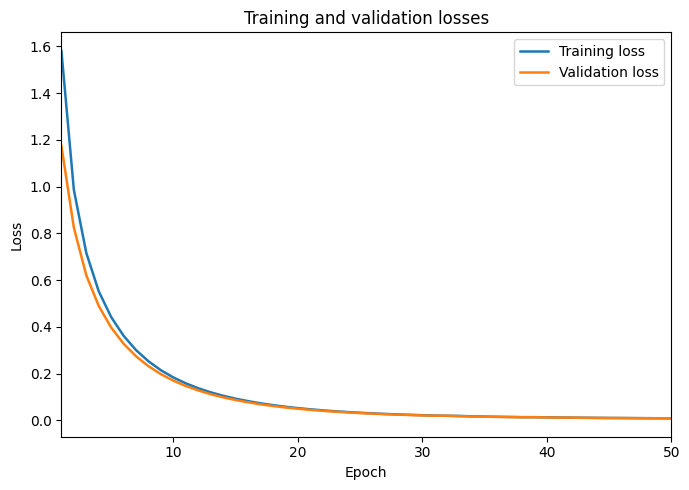

In [6]:

epochs_axis = np.arange(1, len(history_df) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    epochs_axis,
    history_df["loss"],
    linewidth=1.8,
    label="Training loss",
)
ax.plot(
    epochs_axis,
    history_df["val_loss"],
    linewidth=1.8,
    label="Validation loss",
)
ax.set_title("Training and validation losses")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xlim(1, len(epochs_axis))
ax.legend(loc="upper right")
fig.tight_layout()

loss_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_Loss.png"
)
fig.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### 3.2. Training and validation accuracy

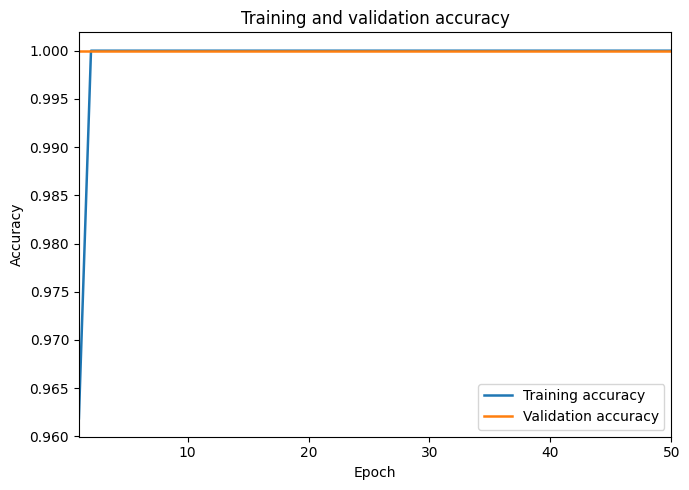

In [7]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    epochs_axis,
    history_df["accuracy"],
    linewidth=1.8,
    label="Training accuracy",
)
ax.plot(
    epochs_axis,
    history_df["val_accuracy"],
    linewidth=1.8,
    label="Validation accuracy",
)
ax.set_title("Training and validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xlim(1, len(epochs_axis))
ax.legend(loc="lower right")
fig.tight_layout()

accuracy_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_Accuracy.png"
)
fig.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 4. Validation performance

All 400 validation images are evaluated using the persisted best `.h5` checkpoint. Because
the validation set is balanced, overall accuracy and balanced accuracy are expected to be
numerically similar, but both are reported together with macro-F1 and per-class metrics.

In [8]:

best_model = load_model(MODEL_PATH)

validation_iterator.reset()

val_probabilities = best_model.predict(
    validation_iterator,
    verbose=1,
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1,
)

val_true = validation_iterator.classes

assert len(val_predictions) == 400

val_accuracy = accuracy_score(
    val_true,
    val_predictions,
)

val_balanced_accuracy = balanced_accuracy_score(
    val_true,
    val_predictions,
)

val_cm = confusion_matrix(
    val_true,
    val_predictions,
)

report_dict = classification_report(
    val_true,
    val_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

macro_precision = float(
    report_dict["macro avg"]["precision"]
)
macro_recall = float(
    report_dict["macro avg"]["recall"]
)
macro_f1 = float(
    report_dict["macro avg"]["f1-score"]
)
weighted_f1 = float(
    report_dict["weighted avg"]["f1-score"]
)

print(f"Validation accuracy:          {val_accuracy:.4f}")
print(
    f"Validation balanced accuracy: "
    f"{val_balanced_accuracy:.4f}"
)
print(f"Macro precision:              {macro_precision:.4f}")
print(f"Macro recall:                 {macro_recall:.4f}")
print(f"Macro F1:                     {macro_f1:.4f}")
print(f"Weighted F1:                  {weighted_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        val_true,
        val_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

pd.DataFrame(report_dict).T.to_csv(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_validation_report.csv"
)

validation_summary = {
    "accuracy": float(val_accuracy),
    "balanced_accuracy": float(val_balanced_accuracy),
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

with open(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_validation_summary.json",
    "w",
) as f:
    json.dump(validation_summary, f, indent=2)

validation_predictions = pd.DataFrame({
    "filename": validation_iterator.filenames,
    "true_label": [
        CLASS_NAMES[i]
        for i in val_true
    ],
    "predicted_label": [
        CLASS_NAMES[i]
        for i in val_predictions
    ],
})

for idx, class_name in enumerate(CLASS_NAMES):
    validation_predictions[
        f"prob_{class_name}"
    ] = val_probabilities[:, idx]

validation_predictions.to_csv(
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_validation_predictions.csv",
    index=False,
)


13/13 [==============================] - 2s 186ms/step
Validation accuracy:          1.0000
Validation balanced accuracy: 1.0000
Macro precision:              1.0000
Macro recall:                 1.0000
Macro F1:                     1.0000
Weighted F1:                  1.0000

Classification report:
              precision    recall  f1-score   support

  Nanodomain     1.0000    1.0000    1.0000       200
     Outside     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400



### 4.1. Validation confusion matrix

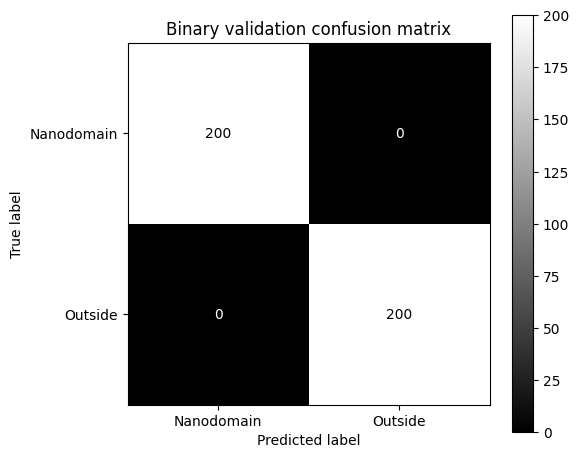

In [9]:

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(val_cm, cmap="gray")
fig.colorbar(im, ax=ax)

ax.set_xticks(
    np.arange(len(CLASS_NAMES))
)
ax.set_yticks(
    np.arange(len(CLASS_NAMES))
)
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    "Binary validation confusion matrix"
)

threshold = val_cm.max() / 2.0

for i in range(val_cm.shape[0]):
    for j in range(val_cm.shape[1]):
        value = int(val_cm[i, j])
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=(
                "black"
                if value > threshold
                else "white"
            ),
        )

fig.tight_layout()

cm_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_Validation_ConfusionMatrix.png"
)

fig.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Independent cross-cell evaluation: restored experimental class-file organization

The 900 balanced cross-cell curves come from a second Candida albicans cell. AtomicJ ROI selection experimentally defined Nanodomain, Intermediate and Outside, with 300 curves per class. Later computational processing restored filename/class organization after anonymization/random renaming; restoration metadata did not define biological labels. Both balanced test archives represent the same cohort.

Use the final self-contained evaluation cell with the published H5 and cross_cell_label_mapping.csv.


In [10]:

if GROUND_TRUTH_CSV.exists():

    extract_zip_clean(
        TEST_ZIP,
        TEST_EXTRACT_DIR,
    )

    # Original archive: filename is the original anonymized image identity.
    labels_df = pd.read_csv(GROUND_TRUTH_CSV)
    required_columns = {"filename", "true_label", "reorganized_filename"}
    if not required_columns.issubset(labels_df.columns):
        raise ValueError("Mapping must contain filename,true_label,reorganized_filename")
    if len(labels_df) != 900 or labels_df[list(required_columns)].isna().any().any():
        raise ValueError("Expected 900 complete mapping rows")
    if any(labels_df[k].duplicated().any() for k in ("filename", "reorganized_filename")):
        raise ValueError("Mapping must be one-to-one")
    if labels_df["true_label"].value_counts().to_dict() != {
        "Nanodomain": 300, "Intermediate": 300, "Outside": 300}:
        raise ValueError("Unexpected experimental class composition")

    binary_labels = labels_df[
        labels_df["true_label"].isin(
            BINARY_CLASSES
        )
    ].copy()

    expected_binary_counts = {
        "Nanodomain": 300,
        "Outside": 300,
    }

    actual_binary_counts = (
        binary_labels["true_label"]
        .value_counts()
        .reindex(
            BINARY_CLASSES,
            fill_value=0,
        )
        .to_dict()
    )

    if actual_binary_counts != expected_binary_counts:
        raise ValueError(
            "Ground-truth CSV does not contain the "
            "expected 300 Nanodomain + 300 Outside "
            f"independent samples: {actual_binary_counts}"
        )

    image_lookup = {
        p.name: p
        for p in TEST_EXTRACT_DIR.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower()
            in SUPPORTED_EXTENSIONS
        )
    }

    missing = [
        filename
        for filename in binary_labels["filename"]
        if filename not in image_lookup
    ]

    if missing:
        raise ValueError(
            f"Missing test images: {missing[:10]}"
        )

    binary_test_files = [
        image_lookup[filename]
        for filename in binary_labels["filename"]
    ]

    def load_binary_test_image(path):
        image_bytes = tf.io.read_file(path)
        image = tf.io.decode_image(
            image_bytes,
            channels=3,
            expand_animations=False,
        )
        image.set_shape(
            [None, None, 3]
        )
        image = tf.image.resize(
            image,
            [IMG_SIZE, IMG_SIZE],
        )
        image = (
            tf.cast(
                image,
                tf.float32,
            )
            / 255.0
        )
        return image

    binary_test_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            [str(p) for p in binary_test_files]
        )
        .map(
            load_binary_test_image,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    test_model = load_model(
        MODEL_PATH
    )

    for warmup_batch in binary_test_ds.take(1):
        _ = test_model(
            warmup_batch,
            training=False,
        )

    test_start = time.perf_counter()

    test_probabilities = (
        test_model.predict(
            binary_test_ds,
            verbose=1,
        )
    )

    test_time_seconds = (
        time.perf_counter()
        - test_start
    )

    test_predictions = np.argmax(
        test_probabilities,
        axis=1,
    )

    y_true = (
        binary_labels["true_label"]
        .to_numpy()
    )

    y_pred = np.array([
        CLASS_NAMES[i]
        for i in test_predictions
    ])

    test_accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    test_balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred,
        )
    )

    test_report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    print(
        "\nIndependent cross-cell binary test"
    )
    print(
        f"Accuracy:          "
        f"{test_accuracy:.4f}"
    )
    print(
        f"Balanced accuracy: "
        f"{test_balanced_accuracy:.4f}"
    )
    print(
        f"Macro F1:          "
        f"{test_report['macro avg']['f1-score']:.4f}"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            labels=CLASS_NAMES,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    test_predictions_df = pd.DataFrame({
        "filename": binary_labels["filename"].to_numpy(),
        "reorganized_filename": binary_labels["reorganized_filename"].to_numpy(),
        "true_label": y_true,
        "predicted_label": y_pred,
    })

    for idx, class_name in enumerate(CLASS_NAMES):
        test_predictions_df[
            f"prob_{class_name}"
        ] = test_probabilities[:, idx]

    test_predictions_df.to_csv(
        RESULTS_DIR
        / f"{EXPERIMENT_NAME}_independent_binary_test_predictions.csv",
        index=False,
    )

    print(
        f"Independent binary test inference time: "
        f"{test_time_seconds:.2f} s"
    )

else:
    print(
        "cross_cell_label_mapping.csv was not found. "
        "The independent 900-curve set is known to contain "
        "300 Nanodomain, 300 Intermediate, and 300 Outside "
        "curves, but the current anonymised filenames are not "
        "mapped to their individual ground-truth classes. "
        "Therefore no sample-level binary independent-test "
        "accuracy is reported."
    )


TestingAdrian_labels.csv was not found. The independent 900-curve set is known to contain 300 Nanodomain, 300 Intermediate, and 300 Outside curves, but the current anonymised filenames are not mapped to their individual ground-truth classes. Therefore no sample-level binary independent-test accuracy is reported.


## 6. Output files

After a complete run, the notebook produces:

- `Models/CNN_CAlbicans_Binary_L2.h5`
- training history and training summary;
- loss and accuracy figures;
- binary validation metrics and confusion matrix;
- validation sample-level predictions;
- optional independent cross-cell binary metrics if `cross_cell_label_mapping.csv` is available.

The complete 16,384-curve AFM map is intentionally **not** classified with this binary model,
because the map contains Intermediate regions and forcing those curves into either Nanodomain
or Outside would not represent the two-class training problem faithfully.